# Step 4 — Delivery Time Modeling

## Objective

Build and compare regression models for predicting `Time_taken(min)`, select a strong candidate using cross-validation, tune its hyperparameters, evaluate it, and save the final pipeline.


## 1. Imports

The notebook uses scikit-learn pipelines for preprocessing, benchmarking, validation, tuning, and evaluation. XGBoost is included as an additional boosting model.


In [2]:
from pathlib import Path

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 5


## 2. Paths

The modeling step reads the dataset produced by feature engineering:

```text
data/processed/food_delivery_features.csv
```

The final model and its metadata are saved under `models/`.


In [4]:
BASE_DIR = Path(f"{Path().cwd()}/step4.ipynb").resolve().parents[1]

DATA_PATH = BASE_DIR / "data" / "food-delivery-features.csv"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Models :", MODEL_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Engineered dataset not found at {DATA_PATH}. "
        "Run 03_feature_engineering.ipynb first."
    )


Dataset: /home/houssam/Desktop/Briefs/Brief 2/data/food-delivery-features.csv
Models : /home/houssam/Desktop/Briefs/Brief 2/models


## 3. Load the engineered dataset

The input is the output of `03_feature_engineering.ipynb`.


In [5]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (41953, 19)


,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Order_Hour,Order_Day,Order_Month,Order_DayOfWeek,Is_Weekend,Pickup_Hour,Preparation_Time_min,Distance_km
0,37.0,4.9,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,11,19,3,5,1,11,15.0,3.025149
1,34.0,4.5,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,19,25,3,4,0,19,5.0,20.183530
2,23.0,4.4,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,8,19,3,5,1,8,15.0,1.552758
3,38.0,4.7,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,18,5,4,1,0,18,10.0,7.790401
4,32.0,4.6,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,13,26,3,5,1,13,15.0,6.210138


## 4. Feature definition

The target is `Time_taken(min)`.

The predictors are grouped according to how they will be preprocessed:

- numeric features;
- categorical features;
- binary features.

`Road_traffic_density` is converted into an ordinal `Traffic_Level` feature.

Additional modeling features are then created:

- distance × traffic interaction;
- distance per delivery;
- preparation-time-to-distance ratio;
- rush-hour indicator;
- cyclical encodings for order hour, pickup hour, day of week, and month.

The original hour/month/day variables are still kept as categorical candidates, while their cyclical versions are added as numeric features.


In [6]:
TARGET = "Time_taken(min)"

TRAFFIC_LEVEL_MAPPING = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Jam": 3,
}

df["Road_traffic_density"] = df["Road_traffic_density"].astype(str).str.strip()
df["Traffic_Level"] = df["Road_traffic_density"].map(TRAFFIC_LEVEL_MAPPING)

if df["Traffic_Level"].isna().any():
    unseen = df.loc[df["Traffic_Level"].isna(), "Road_traffic_density"].unique()
    raise ValueError(f"Unrecognized traffic categories: {unseen}")

NUMERIC_FEATURES = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Distance_km",
    "Order_Day",
    "Preparation_Time_min",
    "Vehicle_condition",
    "Traffic_Level",
]

CATEGORICAL_FEATURES = [
    "Weatherconditions",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
    "Order_Hour",
    "Order_Month",
    "Order_DayOfWeek",
    "Pickup_Hour",
]

BINARY_FEATURES = [
    "Is_Weekend",
]

print("Number of base features:", len(
    NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
))


df["Distance_x_Traffic"] = df["Distance_km"] * df["Traffic_Level"]
df["Distance_per_Delivery"] = df["Distance_km"] / (df["multiple_deliveries"] + 1)
df["Prep_to_Distance_Ratio"] = df["Preparation_Time_min"] / (df["Distance_km"] + 1)

INTERACTION_FEATURES = [
    "Distance_x_Traffic",
    "Distance_per_Delivery",
    "Prep_to_Distance_Ratio",
]

NUMERIC_FEATURES += INTERACTION_FEATURES


RUSH_HOURS = {12, 13, 14, 19, 20, 21}
df["Is_Rush_Hour"] = df["Order_Hour"].isin(RUSH_HOURS).astype(int)

BINARY_FEATURES.append("Is_Rush_Hour")


def add_cyclical_features(df):
    df = df.copy()

    df["Order_Hour_sin"] = np.sin(2 * np.pi * df["Order_Hour"] / 24)
    df["Order_Hour_cos"] = np.cos(2 * np.pi * df["Order_Hour"] / 24)

    df["Pickup_Hour_sin"] = np.sin(2 * np.pi * df["Pickup_Hour"] / 24)
    df["Pickup_Hour_cos"] = np.cos(2 * np.pi * df["Pickup_Hour"] / 24)

    df["Order_Hour_sin2"] = np.sin(2 * np.pi * 2 * df["Order_Hour"] / 24)
    df["Order_Hour_cos2"] = np.cos(2 * np.pi * 2 * df["Order_Hour"] / 24)

    df["Pickup_Hour_sin2"] = np.sin(2 * np.pi * 2 * df["Pickup_Hour"] / 24)
    df["Pickup_Hour_cos2"] = np.cos(2 * np.pi * 2 * df["Pickup_Hour"] / 24)

    df["Order_DayOfWeek_sin"] = np.sin(2 * np.pi * df["Order_DayOfWeek"] / 7)
    df["Order_DayOfWeek_cos"] = np.cos(2 * np.pi * df["Order_DayOfWeek"] / 7)

    df["Order_Month_sin"] = np.sin(2 * np.pi * (df["Order_Month"] - 1) / 12)
    df["Order_Month_cos"] = np.cos(2 * np.pi * (df["Order_Month"] - 1) / 12)

    return df


df = add_cyclical_features(df)

CYCLICAL_FEATURES = [
    "Order_Hour_sin",
    "Order_Hour_cos",
    "Order_Hour_sin2",
    "Order_Hour_cos2",
    "Pickup_Hour_sin",
    "Pickup_Hour_cos",
    "Pickup_Hour_sin2",
    "Pickup_Hour_cos2",
    "Order_DayOfWeek_sin",
    "Order_DayOfWeek_cos",
    "Order_Month_sin",
    "Order_Month_cos",
]

NUMERIC_FEATURES += CYCLICAL_FEATURES

ALL_FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
    + BINARY_FEATURES
)

print("Final number of features:", len(ALL_FEATURES))
print("Features:", ALL_FEATURES)
print("Target:", TARGET)


Number of base features: 18
Final number of features: 34
Features: ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Distance_km', 'Order_Day', 'Preparation_Time_min', 'Vehicle_condition', 'Traffic_Level', 'Distance_x_Traffic', 'Distance_per_Delivery', 'Prep_to_Distance_Ratio', 'Order_Hour_sin', 'Order_Hour_cos', 'Order_Hour_sin2', 'Order_Hour_cos2', 'Pickup_Hour_sin', 'Pickup_Hour_cos', 'Pickup_Hour_sin2', 'Pickup_Hour_cos2', 'Order_DayOfWeek_sin', 'Order_DayOfWeek_cos', 'Order_Month_sin', 'Order_Month_cos', 'Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Order_Hour', 'Order_Month', 'Order_DayOfWeek', 'Pickup_Hour', 'Is_Weekend', 'Is_Rush_Hour']
Target: Time_taken(min)


## 5. Final feature audit

Before modeling, the notebook verifies that:

- the target exists and is excluded from `X`;
- all expected features are present;
- identifiers, raw GPS coordinates, raw datetime columns, and the original traffic column are not used directly;
- the engineered interaction and cyclical features are available.


In [7]:
if TARGET not in df.columns:
    raise ValueError(
        f"The target '{TARGET}' is missing from the dataset."
    )

missing_features = [
    feature
    for feature in ALL_FEATURES
    if feature not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing expected features: {missing_features}"
    )

if TARGET in ALL_FEATURES:
    raise ValueError(
        "The target must not be included in X."
    )

FORBIDDEN_FEATURES = [
    "ID",
    "Delivery_person_ID",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Order_Date",
    "Time_Orderd",
    "Time_Order_picked",
    "Road_traffic_density",
]

forbidden_present = [
    column
    for column in FORBIDDEN_FEATURES
    if column in ALL_FEATURES
]

if forbidden_present:
    raise ValueError(
        f"Raw/forbidden features found in X: {forbidden_present}"
    )

print("✓ Target is present.")
print("✓ Target is not included in X.")
print("✓ Road_traffic_density is replaced by ordinal Traffic_Level.")
print("✓ Vehicle_condition is treated as an ordinal numeric feature.")
print("✓ Raw GPS coordinates are not used.")
print("✓ Raw datetime columns are not used.")
print("✓ Time_Order_picked is not used directly.")
print("✓ Cyclical time features are present.")
print("✓ Interaction features are present.")
print("✓ Final feature audit passed.")


✓ Target is present.
✓ Target is not included in X.
✓ Road_traffic_density is replaced by ordinal Traffic_Level.
✓ Vehicle_condition is treated as an ordinal numeric feature.
✓ Raw GPS coordinates are not used.
✓ Raw datetime columns are not used.
✓ Time_Order_picked is not used directly.
✓ Cyclical time features are present.
✓ Interaction features are present.
✓ Final feature audit passed.


## 6. Target check

`Time_taken(min)` is the regression target. Its distribution and missing values are checked before the train/test split.


In [8]:
print(df[TARGET].describe())

if df[TARGET].isna().any():
    raise ValueError(
        "The target contains missing values."
    )

print(
    "\nMissing target values:",
    df[TARGET].isna().sum()
)


count    41953.000000
mean        26.311539
std          9.380753
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

Missing target values: 0


### 6.1 Distance outliers

The upper 0.5% of `Distance_km` values are removed before model training using the 99.5th percentile as the cutoff.


In [9]:
print(df["Distance_km"].describe())
print("\n99.5th percentile:", df["Distance_km"].quantile(0.995))

DISTANCE_CAP = df["Distance_km"].quantile(0.995)
n_outliers = (df["Distance_km"] > DISTANCE_CAP).sum()
print(f"Observations above the cutoff: {n_outliers}")

df = df[df["Distance_km"] <= DISTANCE_CAP].reset_index(drop=True)
print("New shape:", df.shape)


count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: Distance_km, dtype: float64

99.5th percentile: 20.85246594803466
Observations above the cutoff: 202
New shape: (41751, 36)


## 7. Separate predictors and target

`X` contains only the selected predictors, while `y` contains `Time_taken(min)`.


In [10]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns :")
print(X.columns.tolist())

print("\ny name :", y.name)


X shape: (41751, 34)
y shape: (41751,)

X columns :
['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Distance_km', 'Order_Day', 'Preparation_Time_min', 'Vehicle_condition', 'Traffic_Level', 'Distance_x_Traffic', 'Distance_per_Delivery', 'Prep_to_Distance_Ratio', 'Order_Hour_sin', 'Order_Hour_cos', 'Order_Hour_sin2', 'Order_Hour_cos2', 'Pickup_Hour_sin', 'Pickup_Hour_cos', 'Pickup_Hour_sin2', 'Pickup_Hour_cos2', 'Order_DayOfWeek_sin', 'Order_DayOfWeek_cos', 'Order_Month_sin', 'Order_Month_cos', 'Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'Order_Hour', 'Order_Month', 'Order_DayOfWeek', 'Pickup_Hour', 'Is_Weekend', 'Is_Rush_Hour']

y name : Time_taken(min)


## 8. Train/test split

The dataset is split into:

- **80% training data**
- **20% test data**

`random_state=42` keeps the split reproducible.

Cross-validation and hyperparameter search are performed on the training set.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print(
    f"\nTrain : {len(X_train) / len(X):.1%}"
)

print(
    f"Test  : {len(X_test) / len(X):.1%}"
)


X_train: (33400, 34)
X_test : (8351, 34)
y_train: (33400,)
y_test : (8351,)

Train : 80.0%
Test  : 20.0%


## 9. Preprocessing with `ColumnTransformer`

Three preprocessors are used because the model families have different requirements:

- **Linear models:** median imputation, scaling for numeric features, and one-hot encoding for categorical features.
- **Standard tree models:** median imputation and one-hot encoding, without scaling.
- **HistGradientBoosting:** median imputation plus ordinal encoding for categorical features, with those columns declared as categorical to the estimator.

Binary variables are imputed separately.


In [12]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )

linear_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

linear_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)

linear_binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric_pipeline, NUMERIC_FEATURES),
        ("cat", linear_categorical_pipeline, CATEGORICAL_FEATURES),
        ("bin", linear_binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)


tree_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

tree_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)

tree_binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_pipeline, NUMERIC_FEATURES),
        ("cat", tree_categorical_pipeline, CATEGORICAL_FEATURES),
        ("bin", tree_binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)

from sklearn.preprocessing import OrdinalEncoder

hist_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

hist_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

hist_binary_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

hist_preprocessor = ColumnTransformer(
    transformers=[
        ("num", hist_numeric_pipeline, NUMERIC_FEATURES),
        ("cat", hist_categorical_pipeline, CATEGORICAL_FEATURES),
        ("bin", hist_binary_pipeline, BINARY_FEATURES),
    ],
    remainder="drop",
)

HIST_CATEGORICAL_MASK = (
    [False] * len(NUMERIC_FEATURES)
    + [True] * len(CATEGORICAL_FEATURES)
    + [False] * len(BINARY_FEATURES)
)

print("Preprocessors created: linear, tree, and hist.")


Preprocessors created: linear, tree, and hist.


## 10. Pipeline builders

Each model is wrapped in a pipeline so preprocessing is fitted together with the estimator during training and cross-validation.


In [13]:
def build_linear_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", model),
        ]
    )


def build_tree_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", model),
        ]
    )


def build_hist_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", hist_preprocessor),
            ("model", model),
        ]
    )


## 11. Models included in the benchmark

The benchmark compares several regression families before tuning:

| Model | Main role |
|---|---|
| `DummyRegressor` | Minimum baseline |
| `LinearRegression` | Unregularized linear baseline |
| `Ridge` | Linear regression with L2 regularization |
| `DecisionTreeRegressor` | Single nonlinear tree |
| `RandomForestRegressor` | Bagging ensemble |
| `ExtraTreesRegressor` | More randomized tree ensemble |
| `GradientBoostingRegressor` | Sequential boosting |
| `HistGradientBoostingRegressor` | Histogram-based boosting |

The initial benchmark uses mostly default settings so the model families can be compared before hyperparameter optimization.


## 12. Initial benchmark

All nine models are compared using the same training data and preprocessing protocol.

The benchmark is performed before hyperparameter tuning.


In [14]:
benchmark_models = {
    "DummyRegressor": build_linear_pipeline(
        DummyRegressor(
            strategy="mean"
        )
    ),

    "LinearRegression": build_linear_pipeline(
        LinearRegression()
    ),

    "Ridge": build_linear_pipeline(
        Ridge()
    ),

    "DecisionTreeRegressor": build_tree_pipeline(
        DecisionTreeRegressor(
            random_state=RANDOM_STATE
        )
    ),

    "RandomForestRegressor": build_tree_pipeline(
        RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),

    "ExtraTreesRegressor": build_tree_pipeline(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    ),

    "GradientBoostingRegressor": build_tree_pipeline(
        GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
    ),

    "HistGradientBoostingRegressor": build_hist_pipeline(
        HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            categorical_features=HIST_CATEGORICAL_MASK,
        )
    ),
}


## 13. Cross-validation benchmark

A 5-fold shuffled `KFold` cross-validation is applied to the training set.

The comparison uses:

- RMSE;
- MAE;
- R².

RMSE is the primary ranking metric because it is expressed in minutes and penalizes larger errors more strongly.


In [15]:
cv = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

benchmark_results = []

for model_name, pipeline in benchmark_models.items():
    print(f"Benchmark: {model_name}")

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    benchmark_results.append(
        {
            "Model": model_name,
            "CV_RMSE_mean": -cv_results["test_RMSE"].mean(),
            "CV_RMSE_std": cv_results["test_RMSE"].std(),
            "CV_MAE_mean": -cv_results["test_MAE"].mean(),
            "CV_MAE_std": cv_results["test_MAE"].std(),
            "CV_R2_mean": cv_results["test_R2"].mean(),
            "CV_R2_std": cv_results["test_R2"].std(),
        }
    )

benchmark_results = (
    pd.DataFrame(benchmark_results)
    .sort_values(
        by="CV_RMSE_mean",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    benchmark_results.round(4)
)


Benchmark: DummyRegressor
Benchmark: LinearRegression
Benchmark: Ridge
Benchmark: DecisionTreeRegressor
Benchmark: RandomForestRegressor
Benchmark: ExtraTreesRegressor
Benchmark: GradientBoostingRegressor
Benchmark: HistGradientBoostingRegressor


,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
0,HistGradientBoostingRegressor,3.9563,0.0338,3.1459,0.0161,0.8213,0.0035
1,RandomForestRegressor,4.0171,0.0331,3.1857,0.0124,0.8157,0.0028
2,ExtraTreesRegressor,4.0552,0.0396,3.2114,0.0160,0.8122,0.0030
3,GradientBoostingRegressor,4.5583,0.0262,3.6489,0.0241,0.7628,0.0019
4,DecisionTreeRegressor,5.5211,0.0491,4.1910,0.0402,0.6519,0.0083
5,Ridge,6.0302,0.0514,4.7976,0.0444,0.5848,0.0082
6,LinearRegression,6.0303,0.0514,4.7976,0.0445,0.5848,0.0082
7,DummyRegressor,9.3599,0.0527,7.5675,0.0441,-0.0002,0.0002


## 14. Benchmark comparison

The benchmark plot compares mean cross-validation RMSE across the nine models.

Lower RMSE indicates better predictive performance.


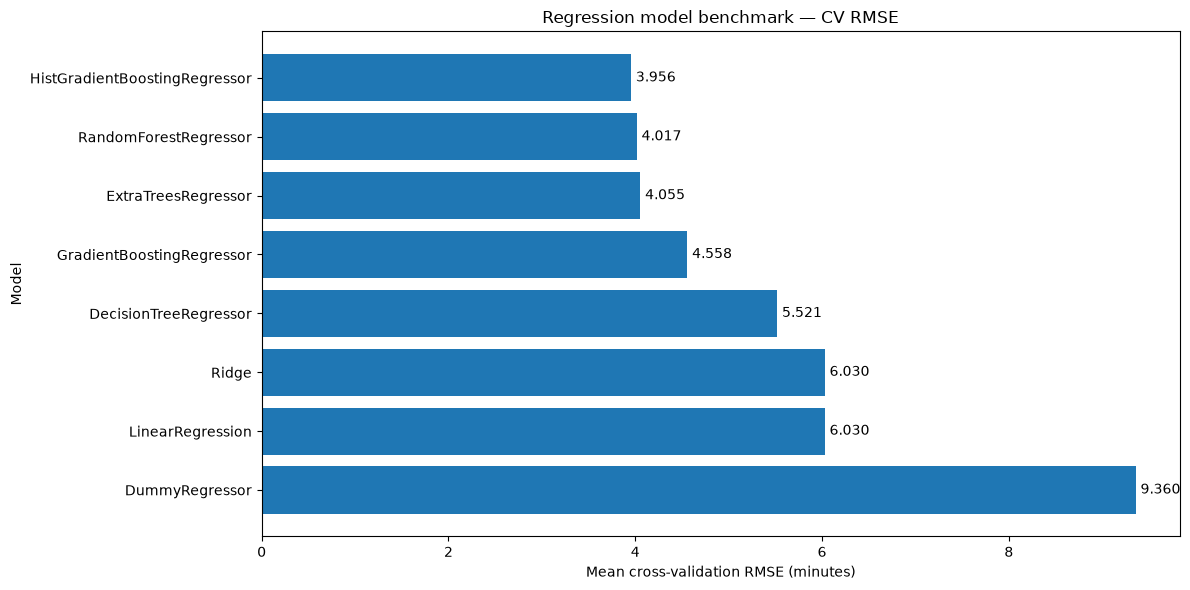

In [16]:
benchmark_plot = benchmark_results.copy()

plt.figure(figsize=(12, 6))

bars = plt.barh(
    benchmark_plot["Model"],
    benchmark_plot["CV_RMSE_mean"],
)

plt.xlabel("Mean cross-validation RMSE (minutes)")
plt.ylabel("Model")
plt.title("Regression model benchmark — CV RMSE")

plt.gca().invert_yaxis()

for bar, value in zip(
    bars,
    benchmark_plot["CV_RMSE_mean"],
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
    )

plt.tight_layout()
plt.show()


## 15. Model shortlist

Based on cross-validation RMSE, four models are retained for closer comparison:

1. `HistGradientBoostingRegressor`
2. `RandomForestRegressor`
3. `ExtraTreesRegressor`
4. `GradientBoostingRegressor`

This shortlist keeps both bagging and boosting approaches while excluding models that were clearly behind in the initial benchmark.


In [17]:
SELECTED_MODEL_NAMES = [
    "HistGradientBoostingRegressor",
    "RandomForestRegressor",
    "ExtraTreesRegressor",
    "GradientBoostingRegressor",
]

print("Models selected for further analysis:")

for rank, model_name in enumerate(
    SELECTED_MODEL_NAMES,
    start=1,
):
    print(f"{rank}. {model_name}")


Models selected for further analysis:
1. HistGradientBoostingRegressor
2. RandomForestRegressor
3. ExtraTreesRegressor
4. GradientBoostingRegressor


## 16. Shortlist results

The selected models are compared using their cross-validation RMSE, MAE, and R².

`HistGradientBoostingRegressor` provides the strongest cross-validation result in the current benchmark and is therefore the main candidate for tuning.


In [18]:
selected_benchmark = benchmark_results[
    benchmark_results["Model"].isin(
        SELECTED_MODEL_NAMES
    )
].copy()

selected_benchmark = selected_benchmark[
    [
        "Model",
        "CV_RMSE_mean",
        "CV_RMSE_std",
        "CV_MAE_mean",
        "CV_MAE_std",
        "CV_R2_mean",
        "CV_R2_std",
    ]
].reset_index(drop=True)

display(
    selected_benchmark.round(4)
)


,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
0,HistGradientBoostingRegressor,3.9563,0.0338,3.1459,0.0161,0.8213,0.0035
1,RandomForestRegressor,4.0171,0.0331,3.1857,0.0124,0.8157,0.0028
2,ExtraTreesRegressor,4.0552,0.0396,3.2114,0.0160,0.8122,0.0030
3,GradientBoostingRegressor,4.5583,0.0262,3.6489,0.0241,0.7628,0.0019


## 17. Selected model families

The four shortlisted models use different tree-based strategies:

| Model | Strategy |
|---|---|
| `HistGradientBoostingRegressor` | Sequential histogram-based boosting |
| `RandomForestRegressor` | Bagging of randomized decision trees |
| `ExtraTreesRegressor` | Tree ensemble with stronger split randomization |
| `GradientBoostingRegressor` | Tree ensemble with stronger split randomization |

This gives a useful comparison between boosting and bagging without repeating the full theory of every estimator.


## 18. Configure the shortlisted models

The four selected estimators are rebuilt with their corresponding preprocessing pipelines.

No hyperparameter search is performed at this stage.


In [19]:
selected_model_factory = {
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        categorical_features=HIST_CATEGORICAL_MASK,
    ),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ExtraTreesRegressor": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
}

selected_pipelines = {}

for model_name in SELECTED_MODEL_NAMES:
    model = selected_model_factory[model_name]

    if model_name in ["LinearRegression", "Ridge"]:
        selected_pipelines[model_name] = build_linear_pipeline(model)
    elif model_name == "HistGradientBoostingRegressor":
        selected_pipelines[model_name] = build_hist_pipeline(model)
    else:
        selected_pipelines[model_name] = build_tree_pipeline(model)

for model_name, pipeline in selected_pipelines.items():
    print(f"\n{model_name}")
    print(pipeline)


HistGradientBoostingRegressor
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'Distance_km', 'Order_Day',
                                                   'Preparation_Time_min',
                                                   'Vehicle_condition',
                                                   'Traffic_Level',
                                                   'Distance_x_Traffic',
                                                   'Distance_per_Delivery',
                            

## 19. Evaluation function

Each fitted model is evaluated with MAE, MSE, RMSE, R², and adjusted R² on both the training and test sets.


In [20]:
def adjusted_r2(
    r2,
    n,
    p,
):
    if n <= p + 1:
        return np.nan

    return 1 - (
        (1 - r2)
        * (n - 1)
        / (n - p - 1)
    )


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    X_train_transformed = (
        model
        .named_steps["preprocessor"]
        .transform(X_train)
    )

    p = X_train_transformed.shape[1]

    train_r2 = r2_score(
        y_train,
        y_train_pred,
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred,
    )

    train_mse = mean_squared_error(
        y_train,
        y_train_pred,
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred,
    )

    return {
        "Train_MAE": mean_absolute_error(
            y_train,
            y_train_pred,
        ),
        "Test_MAE": mean_absolute_error(
            y_test,
            y_test_pred,
        ),
        "Train_MSE": train_mse,
        "Test_MSE": test_mse,
        "Train_RMSE": np.sqrt(train_mse),
        "Test_RMSE": np.sqrt(test_mse),
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Train_Adjusted_R2": adjusted_r2(
            train_r2,
            len(y_train),
            p,
        ),
        "Test_Adjusted_R2": adjusted_r2(
            test_r2,
            len(y_test),
            p,
        ),
        "n_features_after_encoding": p,
    }


## 20. Train the shortlisted models

Each pipeline is fitted on the full training set and evaluated with the same metrics.


In [21]:
comparison_results = []
fitted_models = {}

for model_name, pipeline in selected_pipelines.items():
    print(f"Training: {model_name}")

    pipeline.fit(
        X_train,
        y_train,
    )

    fitted_models[model_name] = pipeline

    metrics = evaluate_model(
        pipeline,
        X_train,
        y_train,
        X_test,
        y_test,
    )

    metrics["Model"] = model_name

    comparison_results.append(metrics)

comparison_results = pd.DataFrame(
    comparison_results
)

comparison_results = (
    comparison_results[
        [
            "Model",
            "Train_MAE",
            "Test_MAE",
            "Train_MSE",
            "Test_MSE",
            "Train_RMSE",
            "Test_RMSE",
            "Train_R2",
            "Test_R2",
            "Train_Adjusted_R2",
            "Test_Adjusted_R2",
            "n_features_after_encoding",
        ]
    ]
    .sort_values(
        by="Test_RMSE",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    comparison_results.round(4)
)


Training: HistGradientBoostingRegressor
Training: RandomForestRegressor
Training: ExtraTreesRegressor
Training: GradientBoostingRegressor


,Model,Train_MAE,Test_MAE,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,Train_Adjusted_R2,Test_Adjusted_R2,n_features_after_encoding
0,HistGradientBoostingRegressor,3.0332,3.1202,14.3559,15.2947,3.7889,3.9108,0.8361,0.8283,0.8360,0.8276,34
1,RandomForestRegressor,1.1707,3.1599,2.1913,15.8737,1.4803,3.9842,0.9750,0.8218,0.9749,0.8199,89
2,ExtraTreesRegressor,0.0000,3.1448,0.0000,15.9407,0.0000,3.9926,1.0000,0.8211,1.0000,0.8191,89
3,GradientBoostingRegressor,3.6516,3.6456,20.7662,20.6500,4.5570,4.5442,0.7630,0.7682,0.7623,0.7657,89


## 21. Performance comparison

The main metrics are:

- **MAE:** average absolute prediction error in minutes;
- **RMSE:** error in minutes with a larger penalty for large mistakes;
- **R²:** proportion of target variance explained by the model.

Adjusted R² is reported as an additional descriptive metric.


In [22]:
comparison_display = comparison_results[
    [
        "Model",
        "Test_MAE",
        "Test_MSE",
        "Test_RMSE",
        "Test_R2",
        "Test_Adjusted_R2",
    ]
].copy()

display(
    comparison_display.round(4)
)   


,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Test_Adjusted_R2
0,HistGradientBoostingRegressor,3.1202,15.2947,3.9108,0.8283,0.8276
1,RandomForestRegressor,3.1599,15.8737,3.9842,0.8218,0.8199
2,ExtraTreesRegressor,3.1448,15.9407,3.9926,0.8211,0.8191
3,GradientBoostingRegressor,3.6456,20.6500,4.5442,0.7682,0.7657


## 22. Train/test gap

Training and test RMSE and R² are compared to identify models whose training performance is much stronger than their performance on unseen data.

A large gap can indicate overfitting.


In [23]:
overfitting_analysis = comparison_results[
    [
        "Model",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
    ]
].copy()

overfitting_analysis["RMSE_gap"] = (
    overfitting_analysis["Test_RMSE"]
    - overfitting_analysis["Train_RMSE"]
)

overfitting_analysis["R2_gap"] = (
    overfitting_analysis["Train_R2"]
    - overfitting_analysis["Test_R2"]
)

display(
    overfitting_analysis.round(4)
)


,Model,Train_RMSE,Test_RMSE,Train_R2,Test_R2,RMSE_gap,R2_gap
0,HistGradientBoostingRegressor,3.7889,3.9108,0.8361,0.8283,0.1219,0.0078
1,RandomForestRegressor,1.4803,3.9842,0.9750,0.8218,2.5039,0.1532
2,ExtraTreesRegressor,0.0000,3.9926,1.0000,0.8211,3.9926,0.1789
3,GradientBoostingRegressor,4.5570,4.5442,0.7630,0.7682,-0.0128,-0.0053


## 23. Train vs test RMSE

The chart shows the training and test RMSE for each shortlisted model.

The goal is not to minimize training error alone, but to retain strong performance on unseen observations.


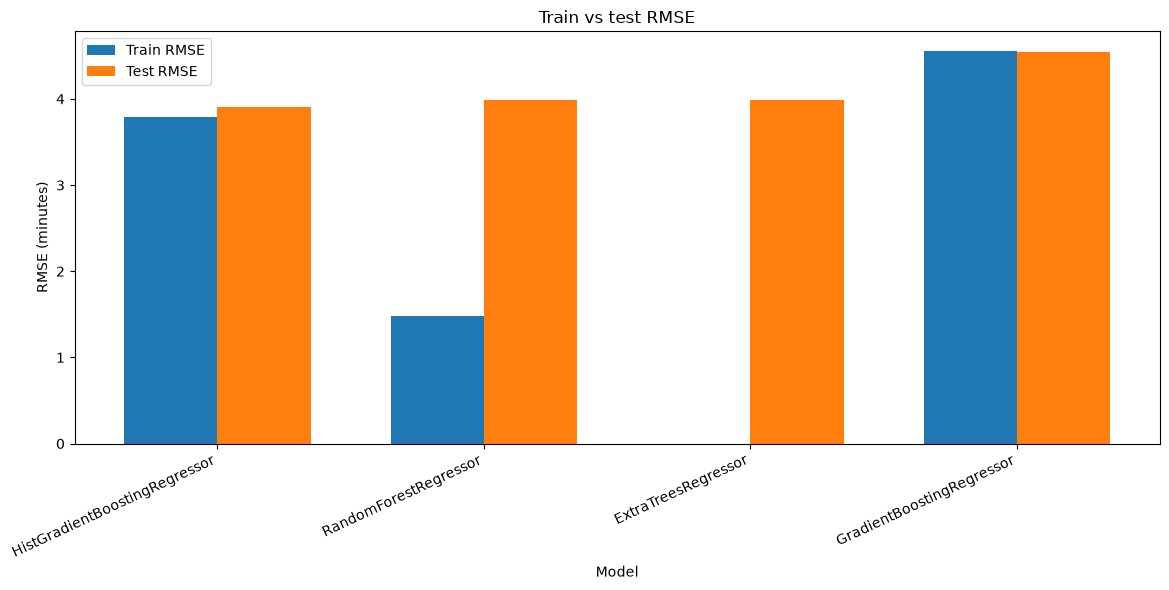

In [24]:
plot_df = comparison_results.copy()

x = np.arange(
    len(plot_df)
)

width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_df["Train_RMSE"],
    width,
    label="Train RMSE",
)

plt.bar(
    x + width / 2,
    plot_df["Test_RMSE"],
    width,
    label="Test RMSE",
)

plt.xticks(
    x,
    plot_df["Model"],
    rotation=25,
    ha="right",
)

plt.ylabel("RMSE (minutes)")
plt.xlabel("Model")
plt.title(
    "Train vs test RMSE"
)

plt.legend()

plt.tight_layout()
plt.show()


## 24. Model selected for tuning

The tuning candidate is selected from the cross-validation benchmark rather than from the test ranking.

`HistGradientBoostingRegressor` has the strongest cross-validation result among the shortlisted models, so it is carried forward as the baseline for hyperparameter optimization.

The train/test comparison above is retained as a diagnostic view of the shortlisted models.


In [25]:
FINAL_MODEL_NAME = "HistGradientBoostingRegressor"

hist_gradient_cv = benchmark_results[
    benchmark_results["Model"] == FINAL_MODEL_NAME
].iloc[0]

hist_gradient_results = comparison_results[
    comparison_results["Model"] == FINAL_MODEL_NAME
].iloc[0]

print("=" * 70)
print("MODEL SELECTED FOR HYPERPARAMETER TUNING")
print("=" * 70)

print(f"\nModel: {FINAL_MODEL_NAME}")
print("\nSelection basis: cross-validation performance on the training set.")

print("\nCross-validation performance:")
print(f"- CV MAE : {hist_gradient_cv['CV_MAE_mean']:.4f} min")
print(f"- CV RMSE: {hist_gradient_cv['CV_RMSE_mean']:.4f} min")
print(f"- CV R²  : {hist_gradient_cv['CV_R2_mean']:.4f}")

print("\nReference train/test diagnostics:")
print(f"- Train RMSE: {hist_gradient_results['Train_RMSE']:.4f} min")
print(f"- Test RMSE : {hist_gradient_results['Test_RMSE']:.4f} min")
print(
    f"- RMSE gap  : "
    f"{hist_gradient_results['Test_RMSE'] - hist_gradient_results['Train_RMSE']:.4f} min"
)


MODEL SELECTED FOR HYPERPARAMETER TUNING

Model: HistGradientBoostingRegressor

Selection basis: cross-validation performance on the training set.

Cross-validation performance:
- CV MAE : 3.1459 min
- CV RMSE: 3.9563 min
- CV R²  : 0.8213

Reference train/test diagnostics:
- Train RMSE: 3.7889 min
- Test RMSE : 3.9108 min
- RMSE gap  : 0.1219 min


## 25. Baseline before tuning

`HistGradientBoostingRegressor` is used as the reference configuration for the optimization stage.

The next step searches for hyperparameters that improve cross-validation RMSE while monitoring the train/test gap after tuning.


## 26. Hyperparameter optimization strategy

`HistGradientBoostingRegressor` has several influential hyperparameters, so optimization is performed in two stages:

1. `RandomizedSearchCV` explores a broad search space efficiently.
2. `GridSearchCV` refines the search around the best region found in stage 1.

Both searches use the same 5-fold cross-validation setup and optimize negative RMSE.


In [26]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform
import time

cv_search = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

SEARCH_SCORING = "neg_root_mean_squared_error"


## 27. Randomized hyperparameter search

The random search explores:

- `learning_rate`;
- `max_iter`;
- `max_leaf_nodes`;
- `max_depth`;
- `min_samples_leaf`;
- `l2_regularization`;
- `max_bins`.

A total of 80 parameter combinations are sampled and evaluated with 5-fold cross-validation.


In [27]:
hist_param_distributions = {
    "model__learning_rate": uniform(0.01, 0.29),
    "model__max_iter": randint(100, 800),
    "model__max_leaf_nodes": randint(15, 255),
    "model__max_depth": [None, 3, 4, 5, 6, 7, 8, 10, 12, 15],
    "model__min_samples_leaf": randint(5, 100),
    "model__l2_regularization": uniform(0.0, 5.0),
    "model__max_bins": randint(64, 255),
}

hist_base_pipeline = build_hist_pipeline(
    HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        categorical_features=HIST_CATEGORICAL_MASK,
    )
)

random_search = RandomizedSearchCV(
    estimator=hist_base_pipeline,
    param_distributions=hist_param_distributions,
    n_iter=80,
    scoring=SEARCH_SCORING,
    cv=cv_search,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start_time = time.time()

random_search.fit(X_train, y_train)

elapsed = time.time() - start_time

print(f"Execution time : {elapsed / 60:.1f} minutes")
print(f"\nBest CV RMSE : {-random_search.best_score_:.4f} min")
print("\nBest hyperparameters :")
for param, value in random_search.best_params_.items():
    print(f"  {param} : {value}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Execution time : 0.9 minutes

Best CV RMSE : 3.9160 min

Best hyperparameters :
  model__l2_regularization : 3.478921996725411
  model__learning_rate : 0.0762795063212169
  model__max_bins : 207
  model__max_depth : 15
  model__max_iter : 723
  model__max_leaf_nodes : 74
  model__min_samples_leaf : 6


## 28. Random-search results

The ten best parameter combinations are sorted by mean cross-validation RMSE before defining the narrower grid.


In [28]:
random_search_results = pd.DataFrame(random_search.cv_results_)

random_search_results["mean_RMSE"] = -random_search_results["mean_test_score"]

top_10 = (
    random_search_results
    .sort_values("mean_RMSE")
    .head(10)
    [
        [
            "mean_RMSE",
            "std_test_score",
            "param_model__learning_rate",
            "param_model__max_iter",
            "param_model__max_leaf_nodes",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "param_model__l2_regularization",
            "param_model__max_bins",
        ]
    ]
    .reset_index(drop=True)
)

display(top_10.round(4))


,mean_RMSE,std_test_score,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__max_depth,param_model__min_samples_leaf,param_model__l2_regularization,param_model__max_bins
0,3.9160,0.0427,0.0763,723,74,15,6,3.4789,207
1,3.9323,0.0341,0.1035,492,57,None,52,1.4765,167
2,3.9356,0.0382,0.0485,769,161,15,21,0.6918,177
3,3.9360,0.0365,0.0764,798,100,8,32,3.7778,223
4,3.9377,0.0404,0.1115,552,75,None,52,2.1720,160
5,3.9377,0.0408,0.1047,437,125,10,57,3.6364,253
6,3.9387,0.0403,0.0931,441,63,15,56,2.7132,121
7,3.9400,0.0292,0.0344,269,151,10,54,0.5056,204
8,3.9414,0.0325,0.0439,173,200,12,21,1.7546,139
9,3.9416,0.0313,0.0470,762,204,10,41,3.6582,159


## 29. Grid-search refinement

A smaller grid is constructed around the best parameters returned by `RandomizedSearchCV`.

`GridSearchCV` then evaluates every combination in this reduced search space.


In [29]:
best_random_params = random_search.best_params_

def build_grid_around(value, deltas, cast=float, min_value=None):
    candidates = sorted(set(cast(value + d) for d in deltas))
    if min_value is not None:
        candidates = [c for c in candidates if c >= min_value]
    return candidates

lr_center = best_random_params["model__learning_rate"]
leaf_nodes_center = best_random_params["model__max_leaf_nodes"]
min_leaf_center = best_random_params["model__min_samples_leaf"]
max_iter_center = best_random_params["model__max_iter"]
l2_center = best_random_params["model__l2_regularization"]

hist_param_grid = {
    "model__learning_rate": build_grid_around(
        lr_center, [-0.03, 0, 0.03], cast=float, min_value=0.01
    ),
    "model__max_iter": sorted(set([
        max(100, max_iter_center - 100),
        max_iter_center,
        max_iter_center + 150,
    ])),
    "model__max_leaf_nodes": sorted(set([
        max(15, leaf_nodes_center - 20),
        leaf_nodes_center,
        leaf_nodes_center + 20,
    ])),
    "model__min_samples_leaf": sorted(set([
        max(5, min_leaf_center - 10),
        min_leaf_center,
        min_leaf_center + 10,
    ])),
    "model__l2_regularization": sorted(set([
        max(0.0, round(l2_center - 0.5, 2)),
        round(l2_center, 2),
        round(l2_center + 0.5, 2),
    ])),
    "model__max_depth": [best_random_params["model__max_depth"]],
    "model__max_bins": [best_random_params["model__max_bins"]],
}

print("Refined GridSearchCV parameter grid :")
for param, values in hist_param_grid.items():
    print(f"  {param} : {values}")

n_combinations = 1
for values in hist_param_grid.values():
    n_combinations *= len(values)
print(f"\nTotal number of combinations : {n_combinations}")


Refined GridSearchCV parameter grid :
  model__learning_rate : [0.0462795063212169, 0.0762795063212169, 0.1062795063212169]
  model__max_iter : [623, 723, 873]
  model__max_leaf_nodes : [54, 74, 94]
  model__min_samples_leaf : [5, 6, 16]
  model__l2_regularization : [np.float64(2.98), np.float64(3.48), np.float64(3.98)]
  model__max_depth : [15]
  model__max_bins : [207]

Total number of combinations : 243


In [30]:
grid_search = GridSearchCV(
    estimator=hist_base_pipeline,
    param_grid=hist_param_grid,
    scoring=SEARCH_SCORING,
    cv=cv_search,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

start_time = time.time()

grid_search.fit(X_train, y_train)

elapsed = time.time() - start_time

print(f"Execution time : {elapsed / 60:.1f} minutes")
print(f"\nBest CV RMSE : {-grid_search.best_score_:.4f} min")
print("\nFinal best hyperparameters :")
for param, value in grid_search.best_params_.items():
    print(f"  {param} : {value}")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Execution time : 3.3 minutes

Best CV RMSE : 3.9023 min

Final best hyperparameters :
  model__l2_regularization : 2.98
  model__learning_rate : 0.0762795063212169
  model__max_bins : 207
  model__max_depth : 15
  model__max_iter : 623
  model__max_leaf_nodes : 94
  model__min_samples_leaf : 5


## 30. Optimization comparison

The baseline, random-search result, and grid-search result are compared using cross-validation RMSE.

This shows whether the additional tuning complexity produces a measurable improvement.


In [31]:
baseline_cv_rmse = benchmark_results.loc[
    benchmark_results["Model"] == "HistGradientBoostingRegressor",
    "CV_RMSE_mean",
].iloc[0]

optimization_comparison = pd.DataFrame([
    {
        "Stage": "Baseline (default parameters)",
        "CV_RMSE": baseline_cv_rmse,
        "combinations_tested": 1,
    },
    {
        "Stage": "RandomizedSearchCV",
        "CV_RMSE": -random_search.best_score_,
        "combinations_tested": 80,
    },
    {
        "Stage": "GridSearchCV refinement",
        "CV_RMSE": -grid_search.best_score_,
        "combinations_tested": n_combinations,
    },
])

optimization_comparison["RMSE_gain_vs_baseline_min"] = (
    optimization_comparison.loc[0, "CV_RMSE"]
    - optimization_comparison["CV_RMSE"]
)

display(optimization_comparison.round(4))


,Stage,CV_RMSE,combinations_tested,RMSE_gain_vs_baseline_min
0,Baseline (default parameters),3.9563,1,0.0000
1,RandomizedSearchCV,3.9160,80,0.0403
2,GridSearchCV refinement,3.9023,243,0.0540


## 31. Final optimized pipeline

`grid_search.best_estimator_` already contains the complete preprocessing and optimized `HistGradientBoostingRegressor` pipeline refitted on the training data.


In [32]:
final_optimized_pipeline = grid_search.best_estimator_

print("Selected final pipeline:")
print(final_optimized_pipeline)

FINAL_BEST_PARAMS = grid_search.best_params_


Selected final pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'Distance_km', 'Order_Day',
                                                   'Preparation_Time_min',
                                                   'Vehicle_condition',
                                                   'Traffic_Level',
                                                   'Distance_x_Traffic',
                                                   'Distance_per_Delivery',
                                  

## 32. Evaluate the optimized model

The optimized pipeline is evaluated with the same train/test metrics used for the baseline.


In [33]:
optimized_metrics = evaluate_model(
    final_optimized_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
)

optimized_metrics["Model"] = "HistGradientBoostingRegressor (optimized)"

optimized_metrics_df = pd.DataFrame([optimized_metrics])[
    [
        "Model",
        "Train_MAE",
        "Test_MAE",
        "Train_MSE",
        "Test_MSE",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2",
        "Train_Adjusted_R2",
        "Test_Adjusted_R2",
        "n_features_after_encoding",
    ]
]

display(optimized_metrics_df.round(4))


,Model,Train_MAE,Test_MAE,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,Train_Adjusted_R2,Test_Adjusted_R2,n_features_after_encoding
0,HistGradientBoostingRegressor (optimized),2.8538,3.0893,12.5507,15.0421,3.5427,3.8784,0.8567,0.8312,0.8566,0.8305,34


## 33. Baseline vs optimized model

The default and optimized `HistGradientBoostingRegressor` configurations are compared directly on the test set.


In [34]:
baseline_row = comparison_results[
    comparison_results["Model"] == "HistGradientBoostingRegressor"
].iloc[0]

final_comparison = pd.DataFrame([
    {
        "Version": "Baseline (default)",
        "Test_MAE": baseline_row["Test_MAE"],
        "Test_RMSE": baseline_row["Test_RMSE"],
        "Test_R2": baseline_row["Test_R2"],
        "Test_Adjusted_R2": baseline_row["Test_Adjusted_R2"],
        "Train_RMSE": baseline_row["Train_RMSE"],
    },
    {
        "Version": "Optimized (GridSearchCV)",
        "Test_MAE": optimized_metrics["Test_MAE"],
        "Test_RMSE": optimized_metrics["Test_RMSE"],
        "Test_R2": optimized_metrics["Test_R2"],
        "Test_Adjusted_R2": optimized_metrics["Test_Adjusted_R2"],
        "Train_RMSE": optimized_metrics["Train_RMSE"],
    },
])

final_comparison["RMSE_gain_min"] = (
    final_comparison.loc[0, "Test_RMSE"]
    - final_comparison["Test_RMSE"]
)

display(final_comparison.round(4))


,Version,Test_MAE,Test_RMSE,Test_R2,Test_Adjusted_R2,Train_RMSE,RMSE_gain_min
0,Baseline (default),3.1202,3.9108,0.8283,0.8276,3.7889,0.0000
1,Optimized (GridSearchCV),3.0893,3.8784,0.8312,0.8305,3.5427,0.0324


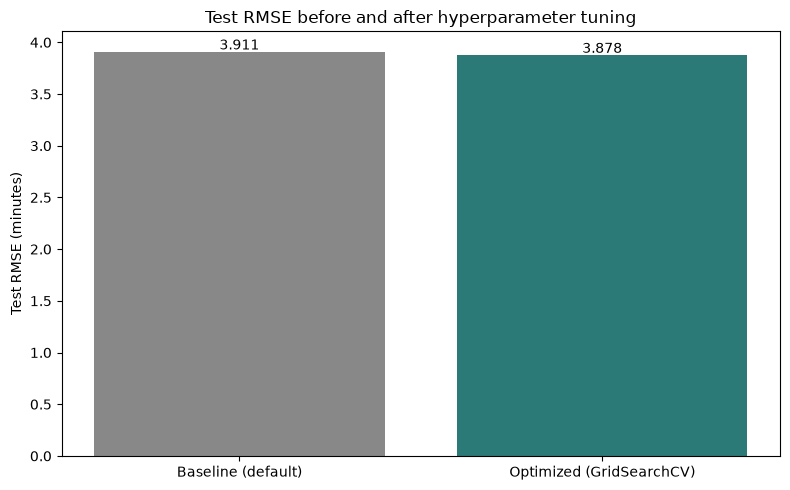

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Version"],
    final_comparison["Test_RMSE"],
    color=["#888888", "#2b7a78"],
)

plt.ylabel("Test RMSE (minutes)")
plt.title("Test RMSE before and after hyperparameter tuning")

for i, value in enumerate(final_comparison["Test_RMSE"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()


## 34. Train/test gap after optimization

The optimized model is checked against the baseline to see whether the performance gain comes with a larger generalization gap.


In [36]:
rmse_gap_optimized = optimized_metrics["Test_RMSE"] - optimized_metrics["Train_RMSE"]
r2_gap_optimized = optimized_metrics["Train_R2"] - optimized_metrics["Test_R2"]

rmse_gap_baseline = baseline_row["Test_RMSE"] - baseline_row["Train_RMSE"]
r2_gap_baseline = baseline_row["Train_R2"] - baseline_row["Test_R2"]

overfitting_comparison = pd.DataFrame([
    {
        "Version": "Baseline",
        "Train_RMSE": baseline_row["Train_RMSE"],
        "Test_RMSE": baseline_row["Test_RMSE"],
        "RMSE_gap": rmse_gap_baseline,
        "R2_gap": r2_gap_baseline,
    },
    {
        "Version": "Optimized",
        "Train_RMSE": optimized_metrics["Train_RMSE"],
        "Test_RMSE": optimized_metrics["Test_RMSE"],
        "RMSE_gap": rmse_gap_optimized,
        "R2_gap": r2_gap_optimized,
    },
])

display(overfitting_comparison.round(4))

if rmse_gap_optimized <= rmse_gap_baseline * 1.2:
    print("The optimized model does not show a notable increase in the train/test gap.")
else:
    print("The optimized model has a larger train/test gap than the baseline.")


,Version,Train_RMSE,Test_RMSE,RMSE_gap,R2_gap
0,Baseline,3.7889,3.9108,0.1219,0.0078
1,Optimized,3.5427,3.8784,0.3357,0.0256


The optimized model has a larger train/test gap than the baseline.


## 35. Practical interpretation

The optimized model reaches approximately:

- **MAE:** 3.09 minutes;
- **RMSE:** 3.88 minutes;
- **R²:** 0.831.

The tuning improvement over the default `HistGradientBoostingRegressor` is small: test RMSE improves by roughly 0.03 minute.

The main conclusion is therefore that the baseline model was already strong, and hyperparameter tuning provides only a marginal additional gain.


In [38]:
test_mae = optimized_metrics["Test_MAE"]
test_rmse = optimized_metrics["Test_RMSE"]
test_r2 = optimized_metrics["Test_R2"]
test_adj_r2 = optimized_metrics["Test_Adjusted_R2"]

gain_rmse = baseline_row["Test_RMSE"] - test_rmse
gain_mae = baseline_row["Test_MAE"] - test_mae

print("=" * 70)
print("OPTIMIZED MODEL — PRACTICAL INTERPRETATION")
print("=" * 70)

print(
    f"\n• MAE: predictions differ from the observed delivery time "
    f"by {test_mae:.2f} minutes on average."
)

print(
    f"\n• RMSE: {test_rmse:.2f} minutes."
)

print(
    f"\n• R²: the model explains {test_r2 * 100:.1f}% of the variance "
    f"in delivery time."
)

print(
    f"\n• Adjusted R²: {test_adj_r2:.4f}."
)

print(
    f"\n• Improvement over the default configuration: "
    f"{gain_rmse:.4f} min RMSE and {gain_mae:.4f} min MAE."
)


OPTIMIZED MODEL — PRACTICAL INTERPRETATION

• MAE: predictions differ from the observed delivery time by 3.09 minutes on average.

• RMSE: 3.88 minutes.

• R²: the model explains 83.1% of the variance in delivery time.

• Adjusted R²: 0.8305.

• Improvement over the default configuration: 0.0324 min RMSE and 0.0309 min MAE.


## 36. Permutation feature importance

Permutation importance measures how much predictive performance deteriorates when one feature is randomly shuffled.

The calculation is performed on the test set with 10 repetitions per feature and is used to identify which inputs the final model relies on most strongly.


In [39]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_optimized_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_mean": perm_importance.importances_mean,
    "Importance_std": perm_importance.importances_std,
}).sort_values("Importance_mean", ascending=False).reset_index(drop=True)

display(importance_df.head(15).round(4))


,Feature,Importance_mean,Importance_std
0,Weatherconditions,3.0860,0.0374
1,Distance_x_Traffic,2.2343,0.0315
2,Delivery_person_Ratings,2.1699,0.0639
3,Delivery_person_Age,1.9657,0.0247
4,Vehicle_condition,1.6714,0.0418
5,Distance_km,1.5005,0.0311
6,Traffic_Level,0.8710,0.0245
7,multiple_deliveries,0.4489,0.0186
8,Order_Hour,0.2165,0.0116
9,Festival,0.1475,0.0156


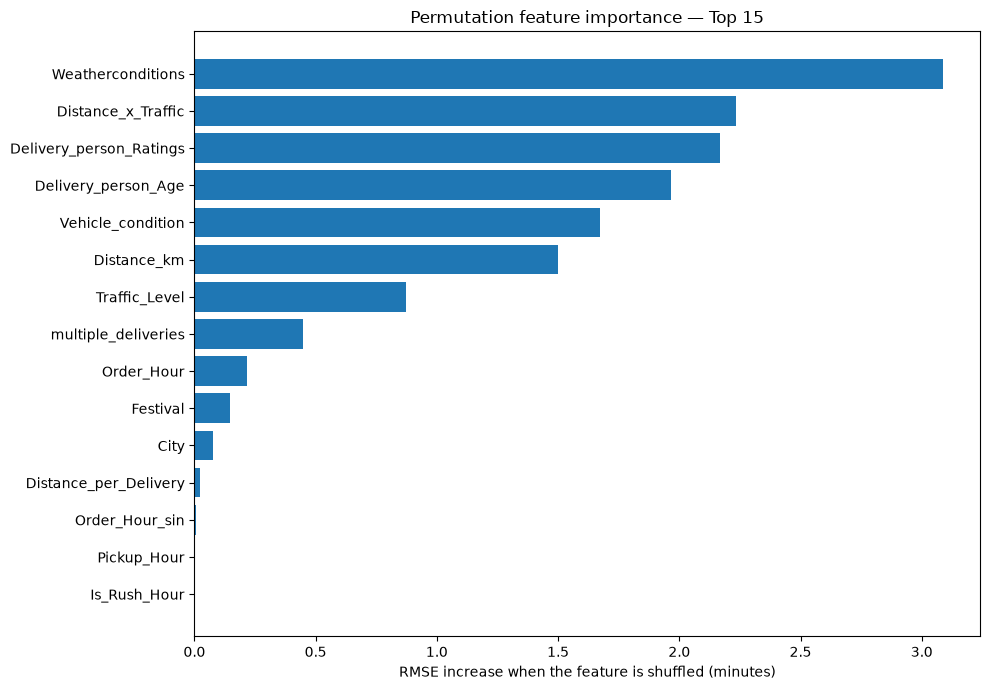

In [40]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("RMSE increase when the feature is shuffled (minutes)")
plt.title("Permutation feature importance — Top 15")
plt.tight_layout()
plt.show()


In [41]:
print("Interpretation:")
print(
    f"\n- The most influential feature is '{top_features.iloc[0]['Feature']}': "
    f"shuffling it increases RMSE by "
    f"{top_features.iloc[0]['Importance_mean']:.3f} minute(s) on average."
)
print(
    "\n- Features with importance close to zero contribute little in this "
    "permutation test and can be investigated further before any removal."
)


Interpretation:

- The most influential feature is 'Weatherconditions': shuffling it increases RMSE by 3.086 minute(s) on average.

- Features with importance close to zero contribute little in this permutation test and can be investigated further before any removal.


## 37. Save the final pipeline

The optimized preprocessing + `HistGradientBoostingRegressor` pipeline is saved with `joblib`.

A separate JSON file stores the selected hyperparameters, expected features, target name, and evaluation metrics for later reuse.


In [42]:
import json

FINAL_MODEL_PATH = MODEL_DIR / "hist_gradient_optimized_pipeline.joblib"
FINAL_METADATA_PATH = MODEL_DIR / "hist_gradient_optimized_metadata.json"

joblib.dump(final_optimized_pipeline, FINAL_MODEL_PATH)

def to_json_value(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value

final_metadata = {
    "model_name": "HistGradientBoostingRegressor",
    "optimization_method": (
        f"RandomizedSearchCV (80 iterations) + "
        f"GridSearchCV ({n_combinations} combinations)"
    ),
    "best_hyperparameters": {
        key.replace("model__", ""): to_json_value(value)
        for key, value in FINAL_BEST_PARAMS.items()
    },
    "features": ALL_FEATURES,
    "target": TARGET,
    "metrics": {
        "cv_rmse_min": float(-grid_search.best_score_),
        "test_mae_min": float(optimized_metrics["Test_MAE"]),
        "test_rmse_min": float(optimized_metrics["Test_RMSE"]),
        "test_r2": float(optimized_metrics["Test_R2"]),
        "test_adjusted_r2": float(optimized_metrics["Test_Adjusted_R2"]),
        "train_rmse_min": float(optimized_metrics["Train_RMSE"]),
        "train_r2": float(optimized_metrics["Train_R2"]),
        "rmse_gap_min": float(rmse_gap_optimized),
        "r2_gap": float(r2_gap_optimized),
    },
    "random_state": RANDOM_STATE,
}

with open(FINAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(final_metadata, f, indent=4, ensure_ascii=False)

print("=" * 70)
print("FINAL MODEL SAVED")
print("=" * 70)
print(f"\nPipeline: {FINAL_MODEL_PATH}")
print(f"Metadata: {FINAL_METADATA_PATH}")

reloaded_pipeline = joblib.load(FINAL_MODEL_PATH)
sample_prediction = reloaded_pipeline.predict(X_test.iloc[:5])

print("\nPipeline reloaded successfully.")
print("Predictions on 5 test samples:", np.round(sample_prediction, 2))
print("Observed values             :", y_test.iloc[:5].values)


FINAL MODEL SAVED

Pipeline: /home/houssam/Desktop/Briefs/Brief 2/models/hist_gradient_optimized_pipeline.joblib
Metadata: /home/houssam/Desktop/Briefs/Brief 2/models/hist_gradient_optimized_metadata.json

Pipeline reloaded successfully.
Predictions on 5 test samples: [28.65 29.77 44.9  36.67 33.13]
Observed values             : [34 33 41 31 33]


## 38. Final summary

`HistGradientBoostingRegressor` was selected from the benchmark and tuned using a broad random search followed by a narrower grid search.

The optimized model improves test RMSE only slightly compared with the default configuration, while the train/test gap becomes somewhat larger.

The final pipeline and its metadata are saved for the next stage.


In [43]:
print("=" * 70)
print("STEP 4 SUMMARY")
print("=" * 70)

print("\nFinal model: HistGradientBoostingRegressor (optimized)")

print("\nSelected hyperparameters:")
for key, value in final_metadata["best_hyperparameters"].items():
    print(f"  - {key}: {value}")

print("\nFinal test performance:")
print(f"  - MAE : {optimized_metrics['Test_MAE']:.4f} min")
print(f"  - RMSE: {optimized_metrics['Test_RMSE']:.4f} min")
print(f"  - R²  : {optimized_metrics['Test_R2']:.4f}")
print(f"  - Adjusted R²: {optimized_metrics['Test_Adjusted_R2']:.4f}")

print("\nImprovement over baseline:")
print(f"  - RMSE: {gain_rmse:.4f} min")
print(f"  - MAE : {gain_mae:.4f} min")

print("\nTrain/test RMSE gap:")
print(f"  - Baseline : {rmse_gap_baseline:.4f} min")
print(f"  - Optimized: {rmse_gap_optimized:.4f} min")

print("\nModel and metadata saved for the next stage.")


STEP 4 SUMMARY

Final model: HistGradientBoostingRegressor (optimized)

Selected hyperparameters:
  - l2_regularization: 2.98
  - learning_rate: 0.0762795063212169
  - max_bins: 207
  - max_depth: 15
  - max_iter: 623
  - max_leaf_nodes: 94
  - min_samples_leaf: 5

Final test performance:
  - MAE : 3.0893 min
  - RMSE: 3.8784 min
  - R²  : 0.8312
  - Adjusted R²: 0.8305

Improvement over baseline:
  - RMSE: 0.0324 min
  - MAE : 0.0309 min

Train/test RMSE gap:
  - Baseline : 0.1219 min
  - Optimized: 0.3357 min

Model and metadata saved for the next stage.
